In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [41]:
df=pd.read_csv("global air pollution dataset.csv")

In [54]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [55]:
X = df[[
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]]

y = df["AQI Value"]

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [58]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
lasso = Lasso(alpha=0.1)

In [60]:
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [61]:
print(lasso.coef_)

[ 0.          4.28564255 -0.09020291 53.55238779]


In [62]:
for feature, coefficient in zip(X.columns, lasso.coef_):
    print(feature, ":", coefficient)

CO AQI Value : 0.0
Ozone AQI Value : 4.2856425479831115
NO2 AQI Value : -0.09020291252007807
PM2.5 AQI Value : 53.5523877898236


In [63]:
selected_features = X.columns[lasso.coef_ != 0]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value'], dtype='object')


In [64]:
y_pred = lasso.predict(X_test_scaled)

print(y_pred[:10])


[ 60.11255231  23.90558858  51.37940662  83.95919572  22.40511606
  55.1545359   31.61666737  45.80810721  66.06227967 253.63423387]


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.783066786874738
MSE: 77.0575253950183
RMSE: 8.77824158900963
R² Score: 0.9758185887616683


In [66]:
for feature, coefficient in zip(X.columns, lasso.coef_):
    print(feature, ":", coefficient)

CO AQI Value : 0.0
Ozone AQI Value : 4.2856425479831115
NO2 AQI Value : -0.09020291252007807
PM2.5 AQI Value : 53.5523877898236


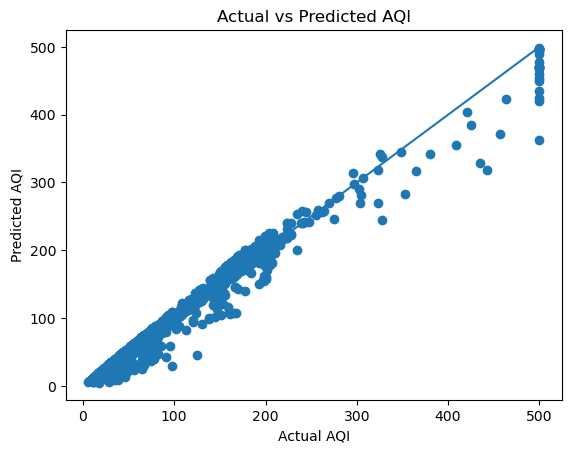

In [67]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()